
Classifying Names with a Character-Level RNN
============================================

We will be building and training a basic character-level Recurrent
Neural Network (RNN) to classify words.

A character-level RNN reads words as a series of characters -outputting
a prediction and \"hidden state\" at each step.

Specifically, we\'ll train on a few thousand surnames from 14 languages
of origin, and predict which language a name is from based on the
spelling.

Preparing Torch
===============

Set up torch to default to the right device use GPU acceleration
depending on your hardware (CPU or CUDA).


In [82]:
import torch

# Check if CUDA is available
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Using device = {torch.get_default_device()}")

Using device = cpu



Preparing the Data
==================

Download the data ("names.zip") from the virtual campus . Included in the `data/names` directory are 14 text files named as
`[Language].txt`. Each file contains a bunch of names, one name per
line, mostly romanized (but we still need to convert from Unicode to
ASCII).

The first step is to define and clean our data. Initially, we need to
convert Unicode to plain ASCII to limit the RNN input layers. This is
accomplished by converting Unicode strings to ASCII and allowing only a small set of allowed characters.


In [83]:


import string
import unicodedata

# We can use "_" to represent an out-of-vocabulary character, that is, any character we are not handling in our model
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)
print(n_letters)

# Turn a Unicode string to plain ASCII
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

58


In [84]:

# Here\'s an example of converting a unicode alphabet name to plain ASCII.
# This simplifies the input layer

print (f"converting 'Ślusàrski' to {unicodeToAscii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski



Turning Names into Tensors
==========================

Now that we have all the names organized, we need to turn them into
Tensors to make any use of them.

To represent a single letter, we use a \"one-hot vector\" of size
`<1 x n_letters>`. A one-hot vector is filled with 0s except for a 1 at
index of the current letter, e.g. `"b" = <0 1 0 0 0 ...>`.

To make a word we join a bunch of those into a 2D matrix
`<line_length x 1 x n_letters>`.

That extra 1 dimension is because PyTorch assumes everything is in
batches - we\'re just using a batch size of 1 here.


In [85]:
# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter: str) -> int:
    # return our out-of-vocabulary character if we encounter a letter unknown to our model
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line: str) -> torch.Tensor:
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x n_letters> tensor (sin dimensión batch intermedia)
# Esta versión es más eficiente para batching
def lineToTensor2D(line: str) -> torch.Tensor:
    tensor = torch.zeros(len(line), n_letters)
    for li, letter in enumerate(line):
        tensor[li][letterToIndex(letter)] = 1
    return tensor

In [86]:

# Here are some examples of how to use `lineToTensor()` for a single and
# multiple character string.

print (f"The letter 'a' becomes {lineToTensor('a')}") #notice that the first position in the tensor = 1
print (f"The name 'Ahn' becomes {lineToTensor('Ahn')}") #notice 'A' sets the 27th index to 1print (f"The letter 'a' becomes {lineToTensor('a')}") #notice that the first position in the tensor = 1

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]])
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0


Next, we need to combine all our examples into a dataset so we can
train, test and validate our models. For this, we will use the [Dataset
and
DataLoader](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)
classes to hold our dataset. Each Dataset needs to implement three
functions: `__init__`, `__len__`, and `__getitem__`. By implementing these three methods, your NamesDataset class becomes compatible with PyTorch's DataLoader, enabling efficient batching and iteration over your data during training and evaluation.

In [87]:

from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

class NamesDataset(Dataset):

    def __init__(self, data_dir: str):
        self.data_dir = data_dir #for provenance of the dataset
        self.load_time = time.localtime #for provenance of the dataset
        labels_set = set() #set of all classes

        self.data: list[str] = []
        self.data_tensors: list[torch.Tensor] = []
        self.labels: list[str] = []
        self.labels_tensors: list[torch.Tensor] = []

        #read all the ``.txt`` files in the specified directory
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor2D(name))  # Usar versión 2D para batching
                self.labels.append(label)

        #Cache the tensor representation of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor(self.labels_uniq.index(self.labels[idx]), dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, str, str]:
        return self.labels_tensors[idx], self.data_tensors[idx], self.labels[idx], self.data[idx]


def collate_names(batch: list) -> tuple[torch.Tensor, torch.nn.utils.rnn.PackedSequence, list[str], list[str]]:
    """
    Collate function para DataLoader que agrupa nombres de diferente longitud.
    Usa pack_padded_sequence para eficiencia en RNNs.
    """
    # Separar los elementos del batch
    labels, tensors, label_names, names = zip(*batch)
    
    # Obtener longitudes originales (antes de padding)
    lengths = torch.tensor([t.size(0) for t in tensors])
    
    # Ordenar por longitud descendente (requerido por pack_padded_sequence)
    lengths_sorted, sort_idx = lengths.sort(descending=True)
    tensors_sorted = [tensors[i] for i in sort_idx]
    labels_sorted = torch.stack([labels[i] for i in sort_idx])
    label_names_sorted = [label_names[i] for i in sort_idx]
    names_sorted = [names[i] for i in sort_idx]
    
    # Pad sequences y crear PackedSequence
    padded = pad_sequence(tensors_sorted, batch_first=False)  # (max_len, batch, n_letters)
    packed = pack_padded_sequence(padded, lengths_sorted.cpu(), batch_first=False)
    
    return labels_sorted, packed, label_names_sorted, names_sorted

In [88]:

# Here we can load our example data into the `NamesDataset`

alldata = NamesDataset("names")
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")


# Using the dataset object allows us to easily split the data into train and test sets. Here we create a 85/15.

loaded 19733 items of data
example = (tensor(12), tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]), 'Czech', 'Abl')


Examples per language:
------------------------------
Russian          9408 ( 47.7%)
English          3668 ( 18.6%)
Arabic           2000 ( 10.1%)
Japanese          991 (  5.0%)
German            724 (  3.7%)
Italian           709 (  3.6%)
Czech             519 (  2.6%)
Spanish           298 (  1.5%)
Dutch             297 (  1.5%)
French            277 (  1.4%)
Chinese           268 (  1.4%)
Irish             232 (  1.2%)
Greek             203 (  1.0%)
Polish            139 (  0.7%)
------------------------------
Total           19733


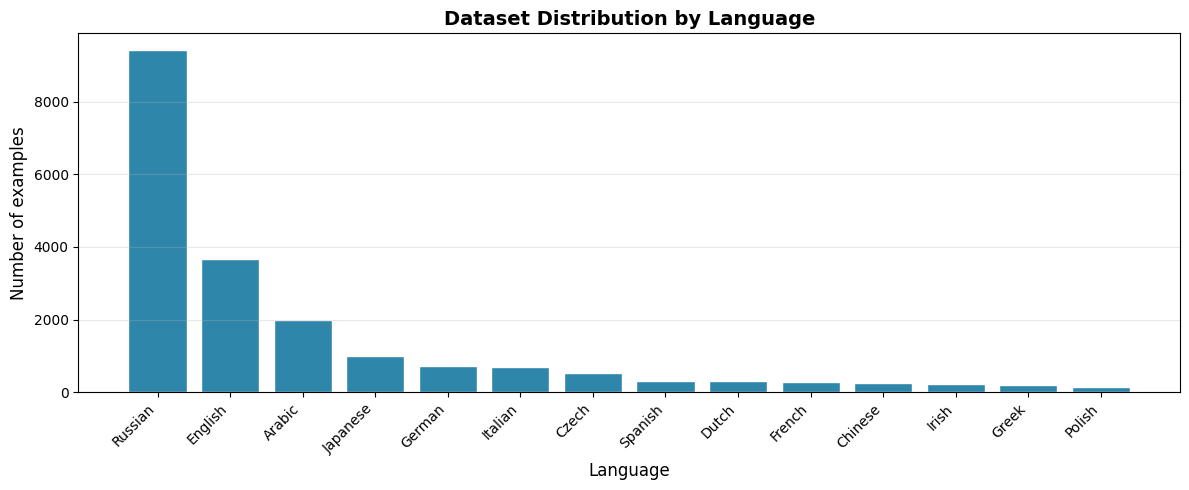

In [ ]:
# Count examples per language
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

language_counts = Counter(alldata.labels)
print("Examples per language:")
print("-" * 30)
for lang, count in sorted(language_counts.items(), key=lambda x: -x[1]):
    print(f"{lang:15} {count:5} ({100*count/len(alldata):5.1f}%)")
print("-" * 30)
print(f"{'Total':15} {len(alldata):5}")

# Bar plot
plt.figure(figsize=(12, 5))
langs = [x[0] for x in sorted(language_counts.items(), key=lambda x: -x[1])]
counts = [language_counts[l] for l in langs]
bars = plt.bar(langs, counts, color='#2E86AB', edgecolor='white')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of examples', fontsize=12)
plt.title('Dataset Distribution by Language', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:


train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device=device).manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 16774, validation examples = 2959



Creating the RNN
====================

This CharRNN class implements an RNN with three components. First, we
use the [nn.RNN
implementation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html).
Next, we define a layer that maps the RNN hidden layers to our output.
And finally, we apply a `softmax` function.


In [90]:


import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x: torch.Tensor | torch.nn.utils.rnn.PackedSequence) -> torch.Tensor:
        """
        Forward pass que acepta tanto tensores individuales como PackedSequence (batched).
        """
        rnn_out, hidden = self.rnn(x)
        # hidden tiene shape (num_layers, batch, hidden_size), tomamos la última capa
        output = self.h2o(hidden[-1])
        output = self.softmax(output)
        return output


class CharFeedForward(nn.Module):
    """
    Red feedforward que usa la suma de los one-hot vectors como input.
    Esto es equivalente a un "bag of characters" - pierde información de orden.
    """
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(CharFeedForward, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x: torch.Tensor | torch.nn.utils.rnn.PackedSequence) -> torch.Tensor:
        # Si es PackedSequence, extraer datos y sumar por secuencia
        if isinstance(x, torch.nn.utils.rnn.PackedSequence):
            # Unpack para obtener el tensor padded
            padded, lengths = pad_packed_sequence(x, batch_first=True)  # (batch, max_len, n_letters)
            # Sumar los caracteres de cada nombre (bag of characters)
            # Usar lengths para no sumar el padding
            batch_size = padded.size(0)
            summed = torch.zeros(batch_size, padded.size(2), device=padded.device)
            for i in range(batch_size):
                summed[i] = padded[i, :lengths[i]].sum(dim=0)
        else:
            # Tensor normal: (seq_len, 1, n_letters) -> sumar sobre seq_len
            summed = x.sum(dim=0)  # (1, n_letters)
        
        # Feedforward
        h = F.relu(self.fc1(summed))
        h = F.relu(self.fc2(h))
        output = self.fc3(h)
        output = self.softmax(output)
        return output

In [ ]:

# We can then create an RNN with 58 input nodes, 128 hidden nodes, and 14
# outputs (one per language):

n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=14, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [92]:

# After that we can pass our Tensor to the RNN to obtain a predicted
# output. From these output classes, the maximum is obtained, so a class is assigned (both numerical and the label of the language).


def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input) #this is equivalent to ``output = rnn.forward(input)``
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.8174, -2.5051, -2.6296, -2.6410, -2.7187, -2.5773, -2.5966, -2.7637,
         -2.6791, -2.5037, -2.6215, -2.7529, -2.6478, -2.5511]],
       grad_fn=<LogSoftmaxBackward0>)
('Italian', 9)



Training the Network
====================

Now all it takes to train this network is show it a bunch of examples,
have it make guesses, and tell it if it's wrong.

We do this by defining a `train()` function which trains the model on a
given dataset using minibatches. RNNs RNNs are trained similarly to
other networks; therefore, for completeness, we include a batched
training method here. The loop (`for i in batch`) computes the losses
for each of the items in the batch before adjusting the weights. This
operation is repeated until the number of epochs is reached.


In [93]:


import numpy as np

def compute_loss(rnn: nn.Module, data, criterion, batch_size: int = 256) -> float:
    """Calcula la loss promedio sobre un dataset sin actualizar gradientes."""
    loader = DataLoader(
        data,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_names,
        generator=torch.Generator(device='cpu')
    )
    rnn.eval()
    total_loss = 0.0
    with torch.no_grad():
        for labels, packed_sequences, _, _ in loader:
            output = rnn(packed_sequences)
            total_loss += criterion(output, labels).item()
    return total_loss / len(loader)


def train(rnn: nn.Module, training_data, test_data=None, n_epoch: int = 30, n_batch_size: int = 64, 
          report_every: int = 5, learning_rate: float = 0.05, criterion = nn.NLLLoss()) -> tuple[list[float], list[float]]:
    """
    Entrena el modelo usando DataLoader con batching real.
    Procesa múltiples nombres en un solo forward pass usando PackedSequence.
    
    Returns:
        (train_losses, test_losses) - listas con la loss por época
    """
    train_losses = []
    test_losses = []
    epoch_times = []
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)
    
    # DataLoader con collate_fn personalizado para batching de secuencias variables
    train_loader = DataLoader(
        training_data, 
        batch_size=n_batch_size, 
        shuffle=True, 
        collate_fn=collate_names,
        generator=torch.Generator(device='cpu')
    )

    print(f"Training on {len(training_data)} examples, {len(train_loader)} batches per epoch")

    for epoch in range(1, n_epoch + 1):
        epoch_start = time.time()
        epoch_loss = 0.0
        
        rnn.train()
        for labels, packed_sequences, _, _ in train_loader:
            optimizer.zero_grad(set_to_none=True)
            
            output = rnn(packed_sequences)
            loss = criterion(output, labels)
            
            loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Calcular loss en test si se proporciona
        if test_data is not None:
            test_loss = compute_loss(rnn, test_data, criterion)
            test_losses.append(test_loss)

        epoch_end = time.time()
        epoch_duration = epoch_end - epoch_start
        epoch_times.append(epoch_duration)
        
        if epoch % report_every == 0:
            avg_epoch_time = sum(epoch_times) / len(epoch_times)
            remaining_epochs = n_epoch - epoch
            eta_seconds = avg_epoch_time * remaining_epochs
            test_str = f" \t test = {test_losses[-1]:.4f}" if test_data is not None else ""
            print(f"{epoch} ({epoch / n_epoch:.0%}): \t train = {avg_train_loss:.4f}{test_str} \t epoch: {epoch_duration:.2f}s \t ETA: {eta_seconds:.1f}s")

    return train_losses, test_losses


We can now train a dataset with minibatches for a specified number of
epochs (def: 30 epochs, learning_rate: 0.05, report every 5 epochs). The number of epochs for this example is reduced to speed up the
build. You can get better results with different parameters.

In [94]:

start = time.time()
train_losses, test_losses = train(rnn, train_set, test_data=test_set, n_epoch=60, learning_rate=0.05, report_every=5)
end = time.time()
print(f"training took {end-start}s")

Training on 16774 examples, 263 batches per epoch


5 (8%): 	 train = 1.0395 	 test = 1.1249 	 epoch: 1.32s 	 ETA: 75.9s
10 (17%): 	 train = 0.8787 	 test = 1.0229 	 epoch: 1.48s 	 ETA: 72.5s
15 (25%): 	 train = 0.7702 	 test = 0.9746 	 epoch: 1.30s 	 ETA: 63.6s
20 (33%): 	 train = 0.7025 	 test = 0.8004 	 epoch: 1.31s 	 ETA: 55.6s
25 (42%): 	 train = 0.6434 	 test = 0.7273 	 epoch: 1.34s 	 ETA: 48.4s
30 (50%): 	 train = 0.5895 	 test = 0.7390 	 epoch: 1.33s 	 ETA: 41.3s
35 (58%): 	 train = 0.5454 	 test = 0.6826 	 epoch: 1.31s 	 ETA: 34.3s
40 (67%): 	 train = 0.5030 	 test = 0.6821 	 epoch: 1.43s 	 ETA: 27.5s
45 (75%): 	 train = 0.4641 	 test = 0.7260 	 epoch: 1.31s 	 ETA: 20.5s
50 (83%): 	 train = 0.4261 	 test = 0.6856 	 epoch: 1.35s 	 ETA: 13.6s
55 (92%): 	 train = 0.3922 	 test = 0.6387 	 epoch: 1.36s 	 ETA: 6.8s
60 (100%): 	 train = 0.3582 	 test = 0.6749 	 epoch: 1.28s 	 ETA: 0.0s
training took 81.656973361969s



Plotting the Results
====================

Plotting the historical loss from `all_losses` shows the network
learning:

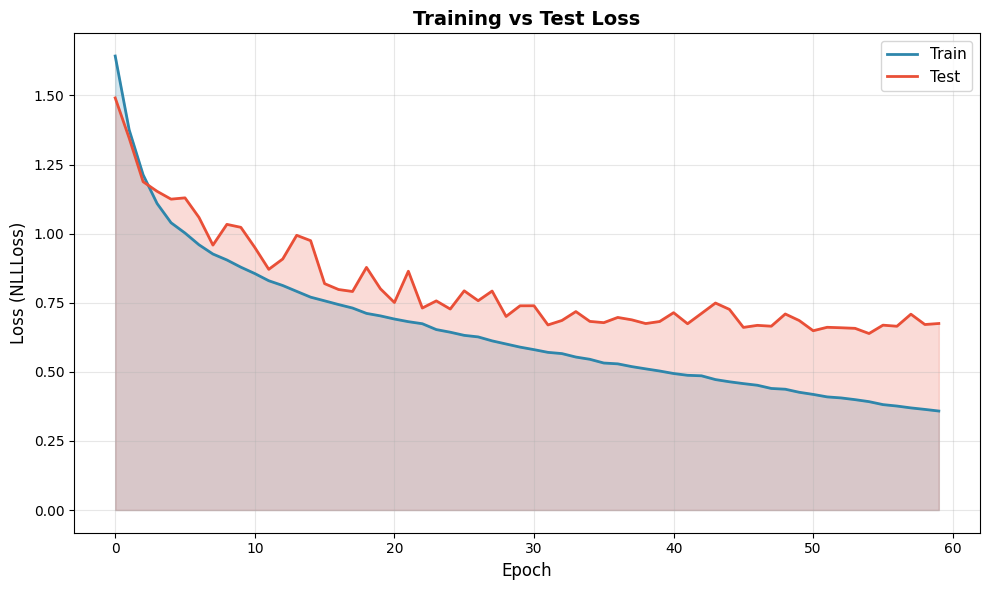

In [95]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))
plt.plot(train_losses, linewidth=2, color='#2E86AB', label='Train')
plt.plot(test_losses, linewidth=2, color='#E94F37', label='Test')
plt.fill_between(range(len(train_losses)), train_losses, alpha=0.2, color='#2E86AB')
plt.fill_between(range(len(test_losses)), test_losses, alpha=0.2, color='#E94F37')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (NLLLoss)', fontsize=12)
plt.title('Training vs Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Evaluating the Results
======================

To see how well the network performs on different categories, we will
create a **confusion matrix**, indicating for every actual language (rows)
which language the network guesses (columns). To calculate the confusion
matrix a bunch of samples are run through the network with `evaluate()`,
which is the same as `train()` minus the backprop.

F1-score and precision (in the weighted form, to take into account for large and small size classes) are also printed.

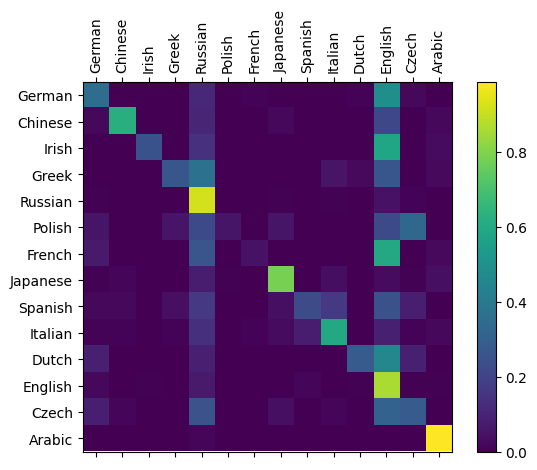


Accuracy: 0.8026
F1-Score (weighted): 0.7867


In [96]:
import sklearn.metrics

def evaluate(rnn: nn.Module, testing_data, classes: list[str], batch_size: int = 256):
    """
    Evalúa el modelo usando batching para mayor eficiencia.
    """
    confusion = torch.zeros(len(classes), len(classes))
    all_true_labels = []
    all_predictions = []

    test_loader = DataLoader(
        testing_data,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_names,
        generator=torch.Generator(device='cpu')
    )

    rnn.eval()
    with torch.no_grad():
        for labels, packed_sequences, label_names, names in test_loader:
            output = rnn(packed_sequences)
            
            # Obtener predicciones para todo el batch
            predictions = output.argmax(dim=1)
            
            for true_label, pred in zip(labels, predictions):
                true_idx = true_label.item()
                pred_idx = pred.item()
                confusion[true_idx][pred_idx] += 1
                all_true_labels.append(true_idx)
                all_predictions.append(pred_idx)

    # Normalize by dividing every row by its sum
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy())
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

    # Calculate and print additional metrics
    accuracy = sklearn.metrics.accuracy_score(all_true_labels, all_predictions)
    f1 = sklearn.metrics.f1_score(all_true_labels, all_predictions, average='weighted')

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")


evaluate(rnn, test_set, classes=alldata.labels_uniq)


Tasks:
=========

- Understand the code.

- Get better results by adjusting the hyperparameters, such as
        changing the size of the hidden layer, number of epochs, batch size, and learning rate.


# Tarea 0: Optimización del entrenamiento mediante batching real

El código original procesaba cada nombre de forma individual en un loop

Esto es muy ineficiente porque:
1. Se realizan N forward passes por batch (uno por nombre)
2. No se aprovecha el paralelismo de las operaciones matriciales
3. El overhead de Python domina el tiempo de ejecución

Para ello, hemos implementado batching real con padding (para poder procesar nombres de longitud diferente)

Con esta optimización, en lugar de 64 (batch size por defecto) forward passes por batch, se realiza un único forward pass que procesa los 64 nombres simultáneamente. Esto reduce significativamente el tiempo de entrenamiento, pasando de 6 minutos a 1.2 minutos.

# Tarea 1: Extraer conclusiones de la matriz de confusión

Lo primero que notamos al mirar la matriz de confusión son dos claras líneas verticales en Russian y English. Esto significa que hay muchos ejemplos donde se predice que el idioma es ruso o inglés de forma incorrecta. Si nos fijamos en la gráfica de arriba donde se ve la distribución de ejemplos por idioma, nos damos cuenta de q precisamente esos dos idiomas son aquellos con mayor número de ejemplos. El hecho de tener una distribución de clases desequilibrada, usando Negative Log Likelihood Loss como función de pérdida, hace que los resultados tiendan a elegir las clases mayoritarias para reducir la pérdida. Por eso vemos esas dos claras franjas verticales.

Vemos que el idioma que mejor se reconoce es el Árabe, que es el tercero por número de ejemplos. Aunque a veces se clasifica como árabe un nombre que no lo es, cuando el nombre es árabe, es prácticamente siempre predicho correctamente. Esto puede deberse a una combinación entre ser una clase mayoritaria y tener nombres distintivos.

RNN vs Feedforward Comparison
=============================

Let's compare the RNN with a feedforward network to see if the sequential nature of the RNN provides a significant advantage for this task.

The feedforward network uses a "bag of characters" approach - it sums all the one-hot vectors, losing the order information. This is similar to how a bag-of-words model works in NLP.

In [97]:
# Create feedforward model with same hidden size as the RNN we already trained
n_hidden = 128
n_classes = len(alldata.labels_uniq)

# Feedforward model (same hidden size, 2 hidden layers to have similar capacity)
ff_model = CharFeedForward(n_letters, n_hidden, n_classes)

# Count parameters
rnn_params = sum(p.numel() for p in rnn.parameters())
ff_params = sum(p.numel() for p in ff_model.parameters())

print(f"RNN parameters (already trained): {rnn_params:,}")
print(f"Feedforward parameters: {ff_params:,}")
print(f"\nFeedforward architecture:\n{ff_model}")

RNN parameters (already trained): 25,870
Feedforward parameters: 25,870

Feedforward architecture:
CharFeedForward(
  (fc1): Linear(in_features=58, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=14, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [98]:
# Train only feedforward (RNN already trained above)
print("Training Feedforward (RNN already trained)...")
print("=" * 60)
ff_train_losses, ff_test_losses = train(
    ff_model, train_set, test_data=test_set, 
    n_epoch=60, learning_rate=0.05, report_every=10
)

Training Feedforward (RNN already trained)...
Training on 16774 examples, 263 batches per epoch


10 (17%): 	 train = 0.9835 	 test = 1.1114 	 epoch: 1.09s 	 ETA: 56.9s
20 (33%): 	 train = 0.7503 	 test = 0.8659 	 epoch: 1.12s 	 ETA: 45.2s
30 (50%): 	 train = 0.6492 	 test = 0.7715 	 epoch: 1.10s 	 ETA: 34.0s
40 (67%): 	 train = 0.5949 	 test = 0.7446 	 epoch: 1.18s 	 ETA: 22.7s
50 (83%): 	 train = 0.5511 	 test = 0.7439 	 epoch: 1.12s 	 ETA: 11.5s
60 (100%): 	 train = 0.5179 	 test = 0.7224 	 epoch: 1.09s 	 ETA: 0.0s


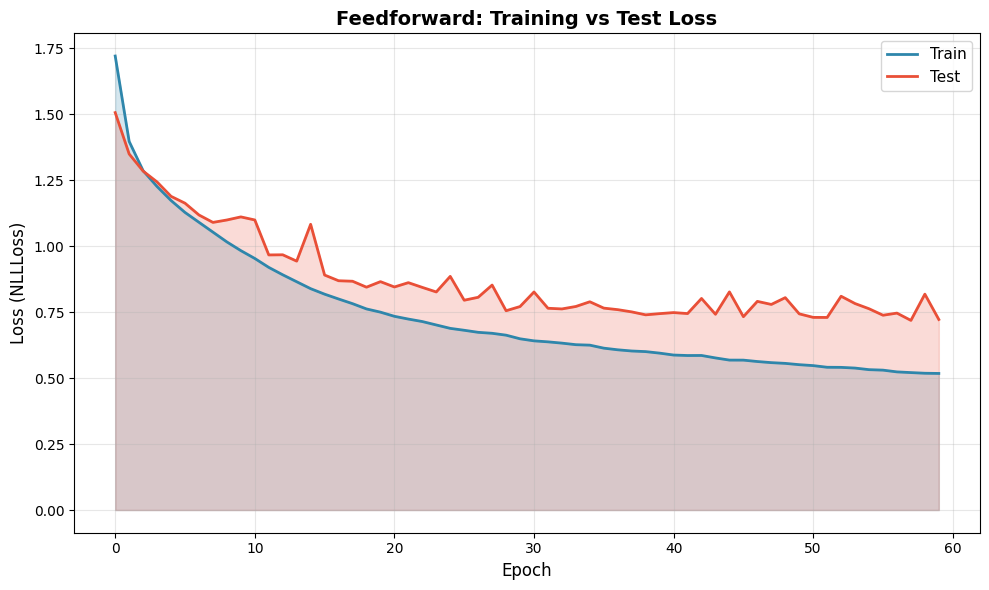

In [101]:
# Plot Feedforward train vs test (same style as RNN plot)
plt.figure(figsize=(10, 6))
plt.plot(ff_train_losses, linewidth=2, color='#2E86AB', label='Train')
plt.plot(ff_test_losses, linewidth=2, color='#E94F37', label='Test')
plt.fill_between(range(len(ff_train_losses)), ff_train_losses, alpha=0.2, color='#2E86AB')
plt.fill_between(range(len(ff_test_losses)), ff_test_losses, alpha=0.2, color='#E94F37')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (NLLLoss)', fontsize=12)
plt.title('Feedforward: Training vs Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

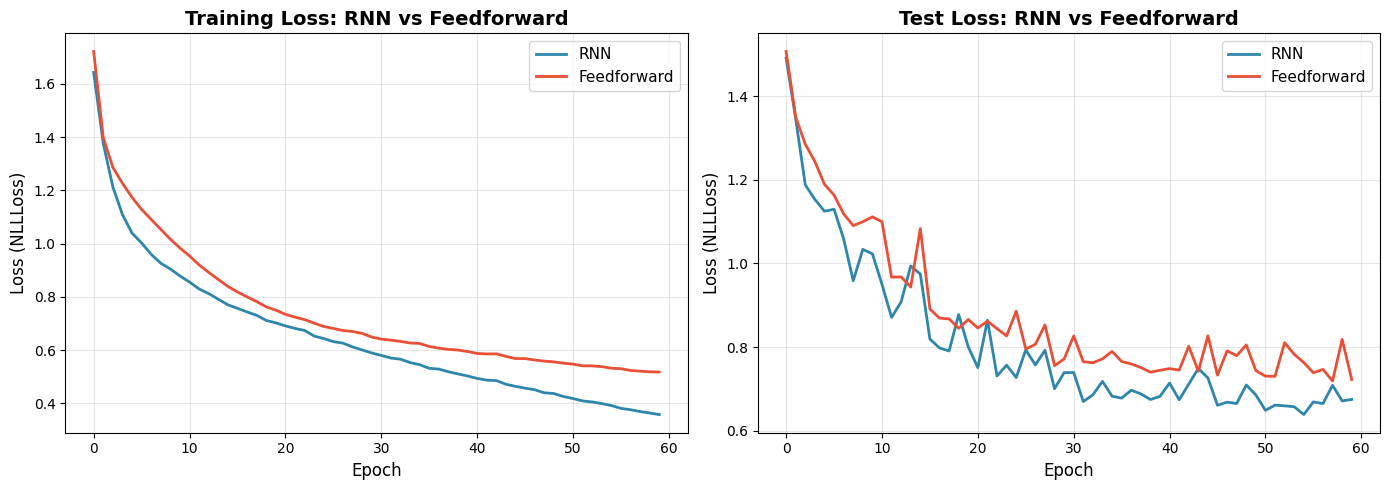


Final Test Loss:
  RNN:         0.6749
  Feedforward: 0.7224
  Difference:  0.0475 (RNN wins)


In [102]:
# Comparison plot: RNN vs Feedforward
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss comparison
axes[0].plot(train_losses, linewidth=2, color='#2E86AB', label='RNN')
axes[0].plot(ff_train_losses, linewidth=2, color='#E94F37', label='Feedforward')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (NLLLoss)', fontsize=12)
axes[0].set_title('Training Loss: RNN vs Feedforward', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Test loss comparison
axes[1].plot(test_losses, linewidth=2, color='#2E86AB', label='RNN')
axes[1].plot(ff_test_losses, linewidth=2, color='#E94F37', label='Feedforward')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (NLLLoss)', fontsize=12)
axes[1].set_title('Test Loss: RNN vs Feedforward', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final losses
print(f"\nFinal Test Loss:")
print(f"  RNN:         {test_losses[-1]:.4f}")
print(f"  Feedforward: {ff_test_losses[-1]:.4f}")
print(f"  Difference:  {ff_test_losses[-1] - test_losses[-1]:.4f} ({'RNN wins' if test_losses[-1] < ff_test_losses[-1] else 'Feedforward wins'})")

RNN Evaluation (already trained):


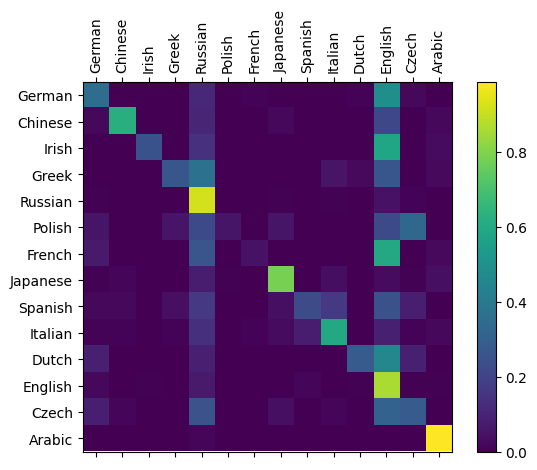


Accuracy: 0.8026
F1-Score (weighted): 0.7867

Feedforward Evaluation:


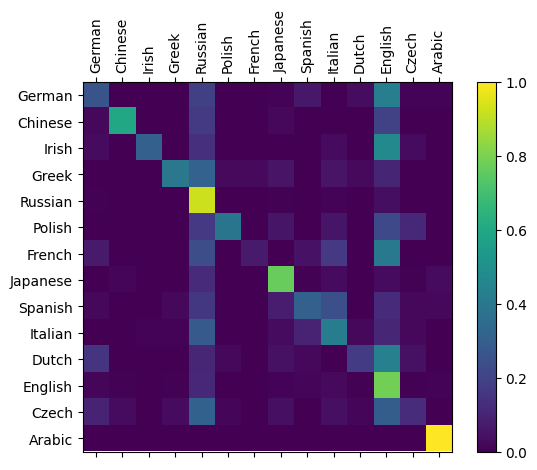


Accuracy: 0.7827
F1-Score (weighted): 0.7647


In [100]:
# Evaluate both models with accuracy and F1
print("=" * 60)
print("RNN Evaluation (already trained):")
print("=" * 60)
evaluate(rnn, test_set, classes=alldata.labels_uniq)

print("\n" + "=" * 60)
print("Feedforward Evaluation:")
print("=" * 60)
evaluate(ff_model, test_set, classes=alldata.labels_uniq)

# Tarea 2: Comparación entre RNN y red Feedforward

Para comparar los resultados entre una red recurrente y una feedforward, hemos tenido que cambiar el formato del input. Mientras que una red recurrente recibe los caracteres uno tras otro, una FFN necesita recibirlos todos a la vez, por eso hemos optado por una representación de "bag of characters" similar a BoW.

Por una parte, esta representación tiende a ser única para nombres más largos, pero puede causar problemas para los apellidos más cortos, donde dos palabras diferentes pueden tener la misma representación. Por otra parte, esta representación pierde cierta información sobre los apellidos, porque ciertas secuencias de caracteres, como O' (que se convertiría en O_) son únicas de los nombres irlandeses y no se encuentran en ningún otro. Pero esta información se pierde al usar una representación de BoC.

Además de una representación diferente, para que sea justa la comparación, hemos introducido dos capas ocultas en la FFN, para que tengan el mismo número de parámetros entrenables.

Al entrenar ambas redes y calcular la pérdida sobre el conjunto de validación, vemos que la diferencia no es demasiado grande (RNN 0.67 vs FFN 0.72 en pérdida, RNN 0.80 vs FFN 0.78 en accuracy). Las dos redes tienden a tener una pérdida y precisión similar. Sin embargo, la red recurrente es mejor en este caso, debido a la ventaja de poder capturar la secuencialidad de los caracteres y los problemas mencionados de usar la representación de BoC.